# OCTA-500 数据集可视化

本 Notebook 按病例编号展示数据集中各输入模态和标注。默认病例 `10001` 属于 6 mm 子集；病例 `10301`—`10500` 属于 3 mm 子集。

- **OCT**：结构性光学相干断层成像的 en-face 投影。
- **OCTA**：血流/血管造影的 en-face 投影。
- **FULL**：完整深度范围投影。
- **ILM_OPL**：ILM 至 OPL 层之间的投影。
- **OPL_BM**：OPL 至 BM 层之间的投影。
- **GT**：Ground Truth，人工标注。

> 提示：将下面的 `CASE_ID` 改为 `10001`—`10500` 中任意编号即可查看其他病例。

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.io import loadmat

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

# 自动兼容从项目根目录或其他位置启动 Notebook 的情况。
candidates = [
    Path.cwd() / "data" / "OCTA-500数据集",
    Path.cwd().parent / "data" / "OCTA-500数据集",
]
DATA_ROOT = next((path.resolve() for path in candidates if path.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError("未找到 data/OCTA-500数据集，请检查 Notebook 的启动目录。")

print(f"数据集路径：{DATA_ROOT}")

数据集路径：/root/workplace/data/OCTA-500数据集


In [2]:
# 修改这里以选择病例。
CASE_ID = 10001

if not 10001 <= CASE_ID <= 10500:
    raise ValueError("CASE_ID 必须位于 10001—10500。")

SCAN_SIZE = "6mm" if CASE_ID <= 10300 else "3mm"
CASE_NAME = str(CASE_ID)
print(f"当前病例：{CASE_NAME}｜扫描范围：{SCAN_SIZE}")

当前病例：10001｜扫描范围：6mm


In [3]:
def load_bmp(path: Path) -> np.ndarray:
    """读取单通道 BMP，并返回二维 NumPy 数组。"""
    if not path.exists():
        raise FileNotFoundError(path)
    with Image.open(path) as image:
        return np.asarray(image.convert("L")).copy()


def load_mat_variable(path: Path, variable: str) -> np.ndarray:
    """同时支持传统 MAT 和 MATLAB v7.3(HDF5) 文件。"""
    if not path.exists():
        raise FileNotFoundError(path)
    try:
        data = loadmat(path)
        if variable not in data:
            raise KeyError(f"{path.name} 中不存在变量 {variable}")
        return np.asarray(data[variable])
    except NotImplementedError:
        with h5py.File(path, "r") as file:
            if variable not in file:
                raise KeyError(f"{path.name} 中不存在变量 {variable}")
            return np.asarray(file[variable])


def hide_axis(axis):
    axis.set_xticks([])
    axis.set_yticks([])


def describe(array: np.ndarray) -> str:
    return f"shape={array.shape}, range=[{array.min()}, {array.max()}]"

## 1. 六种输入图像

同一病例包含 OCT、OCTA 两类成像，以及 FULL、ILM–OPL、OPL–BM 三种深度投影，共 6 幅输入图像。

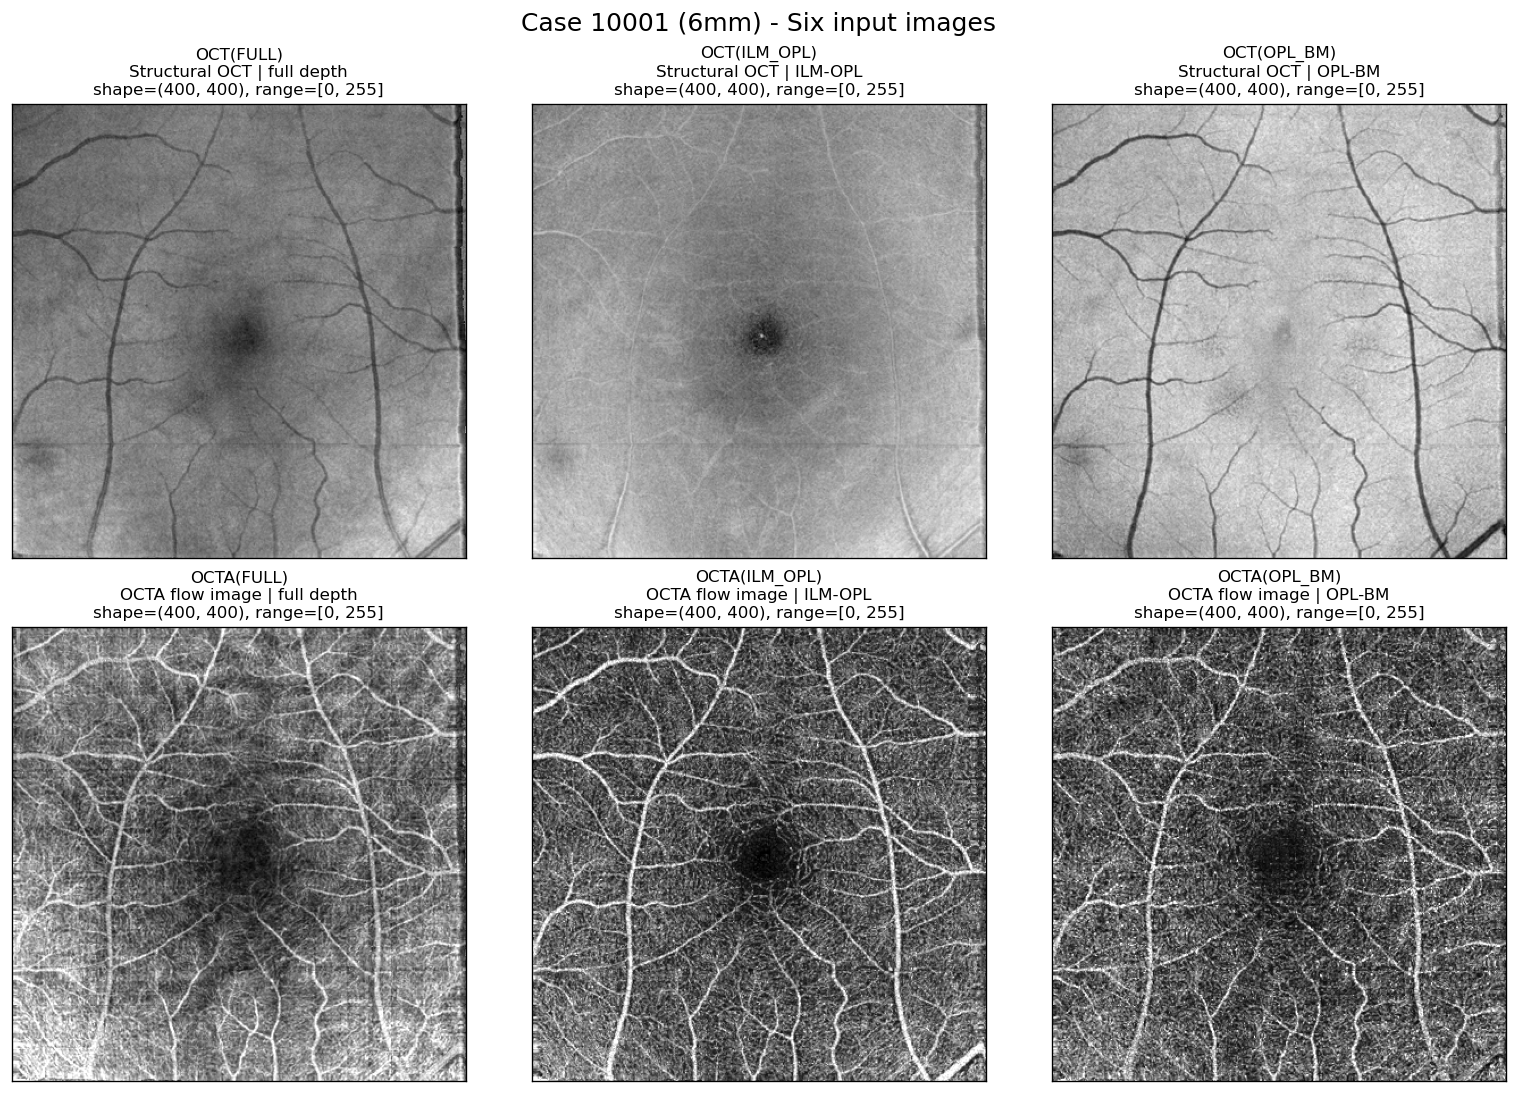

In [4]:
input_images = [
    ("OCT(FULL)", "Structural OCT | full depth"),
    ("OCT(ILM_OPL)", "Structural OCT | ILM-OPL"),
    ("OCT(OPL_BM)", "Structural OCT | OPL-BM"),
    ("OCTA(FULL)", "OCTA flow image | full depth"),
    ("OCTA(ILM_OPL)", "OCTA flow image | ILM-OPL"),
    ("OCTA(OPL_BM)", "OCTA flow image | OPL-BM"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9), constrained_layout=True)
for axis, (folder, meaning) in zip(axes.flat, input_images):
    image = load_bmp(DATA_ROOT / SCAN_SIZE / folder / f"{CASE_NAME}.bmp")
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"{folder}\n{meaning}\n{describe(image)}", fontsize=10)
    hide_axis(axis)
fig.suptitle(f"Case {CASE_NAME} ({SCAN_SIZE}) - Six input images", fontsize=15)
plt.show()

## 2. 六种二维标注

除 `GT_CAVF` 外，其余二维标注均为二值掩膜（背景 0、前景 255）。`GT_CAVF` 是 0—4 的五类别标注，因此使用离散颜色显示。

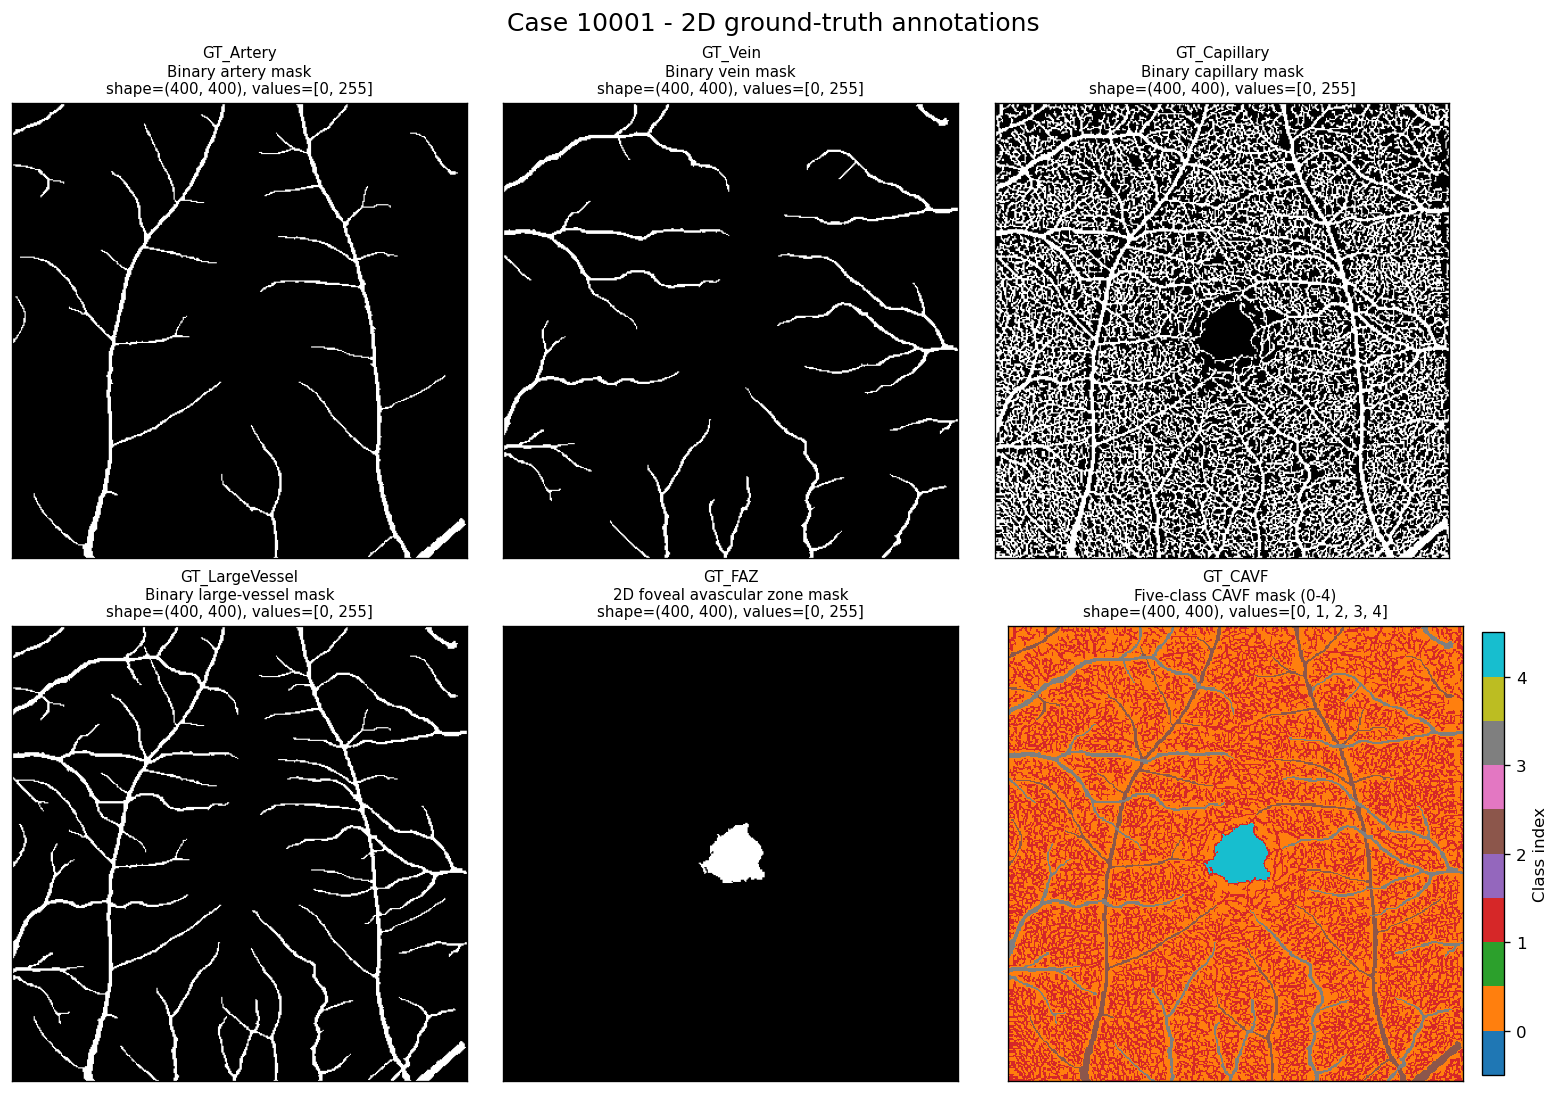

In [5]:
label_images = [
    ("GT_Artery", "Binary artery mask"),
    ("GT_Vein", "Binary vein mask"),
    ("GT_Capillary", "Binary capillary mask"),
    ("GT_LargeVessel", "Binary large-vessel mask"),
    ("GT_FAZ", "2D foveal avascular zone mask"),
    ("GT_CAVF", "Five-class CAVF mask (0-4)"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9), constrained_layout=True)
for axis, (folder, meaning) in zip(axes.flat, label_images):
    mask = load_bmp(DATA_ROOT / "labels" / folder / f"{CASE_NAME}.bmp")
    if folder == "GT_CAVF":
        shown = axis.imshow(mask, cmap="tab10", vmin=-0.5, vmax=4.5, interpolation="nearest")
        colorbar = fig.colorbar(shown, ax=axis, ticks=range(5), fraction=0.046, pad=0.04)
        colorbar.set_label("Class index")
    else:
        axis.imshow(mask, cmap="gray", vmin=0, vmax=255)
    values = np.unique(mask)
    axis.set_title(f"{folder}\n{meaning}\nshape={mask.shape}, values={values.tolist()}", fontsize=9)
    hide_axis(axis)
fig.suptitle(f"Case {CASE_NAME} - 2D ground-truth annotations", fontsize=15)
plt.show()

## 3. 三维 FAZ 标注（GT_FAZ3D）

`FAZlabel` 是三维二值体数据。下面依次展示二维 FAZ 标注、三维标注沿深度方向的最大投影，以及三维体数据的中央剖面。最大投影用于快速检查三维标注与二维标注是否大体对应。

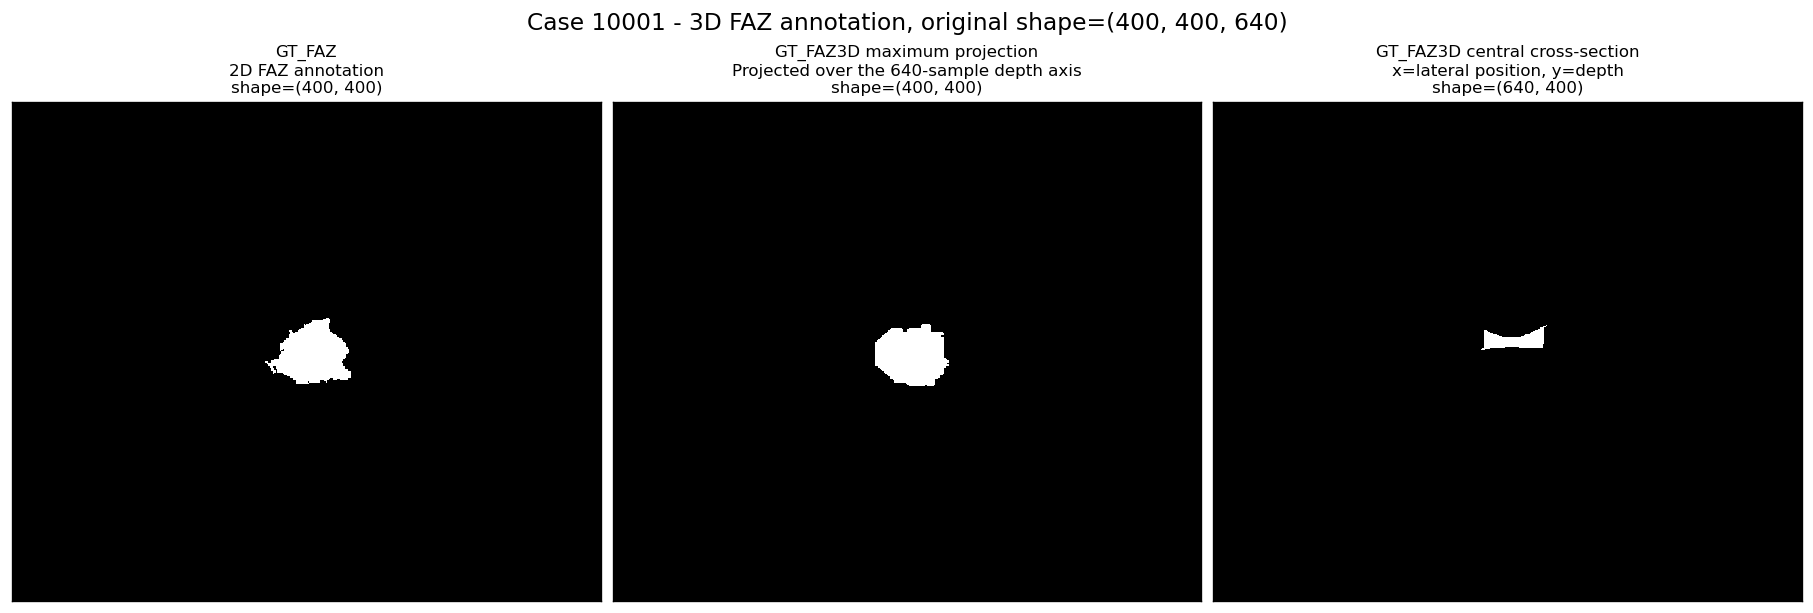

In [6]:
faz_2d = load_bmp(DATA_ROOT / "labels" / "GT_FAZ" / f"{CASE_NAME}.bmp")
faz_3d = load_mat_variable(
    DATA_ROOT / "labels" / "GT_FAZ3D" / f"{CASE_NAME}.mat",
    "FAZlabel",
)

# OCTA-500 的 FAZlabel 为 (H, W, 640)，把长度为 640 的轴统一放到最后。
depth_axes = [axis for axis, size in enumerate(faz_3d.shape) if size == 640]
if len(depth_axes) != 1:
    raise ValueError(f"无法判断深度轴，FAZlabel shape={faz_3d.shape}")
faz_3d = np.moveaxis(faz_3d, depth_axes[0], -1)
faz_projection = faz_3d.max(axis=-1)
faz_center_slice = faz_3d[:, faz_3d.shape[1] // 2, :]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
panels = [
    (faz_2d, "GT_FAZ\n2D FAZ annotation", "gray"),
    (faz_projection, "GT_FAZ3D maximum projection\nProjected over the 640-sample depth axis", "gray"),
    (faz_center_slice.T, "GT_FAZ3D central cross-section\nx=lateral position, y=depth", "gray"),
]
for axis, (image, title, cmap) in zip(axes, panels):
    axis.imshow(image, cmap=cmap, aspect="auto", interpolation="nearest")
    axis.set_title(f"{title}\nshape={image.shape}", fontsize=10)
    hide_axis(axis)
fig.suptitle(f"Case {CASE_NAME} - 3D FAZ annotation, original shape={faz_3d.shape}", fontsize=14)
plt.show()

## 4. 六个视网膜层面（GT_Layers）

变量 `Layer` 的形状为 `(6, H, W)`；每个像素保存对应层面在原始 OCT 体数据中的深度坐标，而不是普通的 0/1 分割掩膜。颜色越亮表示深度坐标越大。

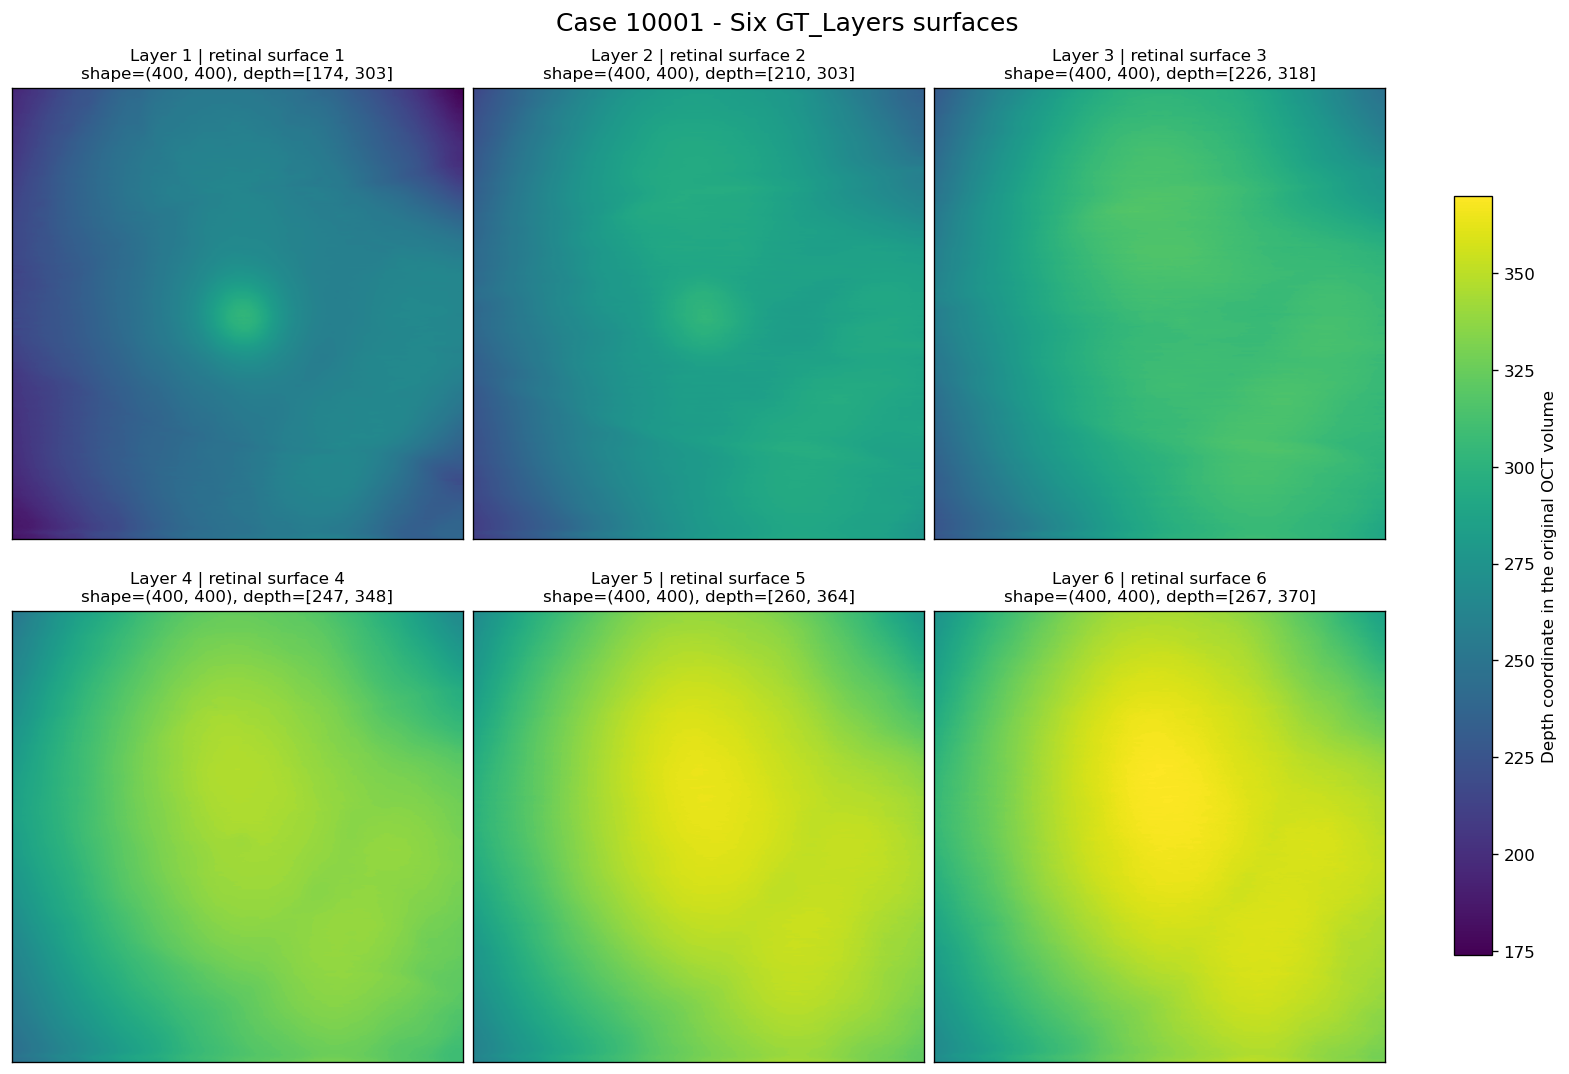

In [7]:
layers = load_mat_variable(
    DATA_ROOT / "labels" / "GT_Layers" / f"{CASE_NAME}.mat",
    "Layer",
)
if layers.ndim != 3 or layers.shape[0] != 6:
    raise ValueError(f"预期 Layer shape=(6, H, W)，实际为 {layers.shape}")

global_min, global_max = layers.min(), layers.max()
fig, axes = plt.subplots(2, 3, figsize=(13, 9), constrained_layout=True)
for index, axis in enumerate(axes.flat):
    surface = layers[index]
    shown = axis.imshow(surface, cmap="viridis", vmin=global_min, vmax=global_max)
    axis.set_title(
        f"Layer {index + 1} | retinal surface {index + 1}\n"
        f"shape={surface.shape}, depth=[{surface.min()}, {surface.max()}]",
        fontsize=10,
    )
    hide_axis(axis)
fig.colorbar(shown, ax=axes, shrink=0.75, label="Depth coordinate in the original OCT volume")
fig.suptitle(f"Case {CASE_NAME} - Six GT_Layers surfaces", fontsize=15)
plt.show()

## 读取数据时的注意事项

1. 3 mm 图像为 `304×304`，6 mm 图像为 `400×400`。联合训练前需要统一尺寸或分别建模。
2. 普通二值 BMP 标签的值为 `0/255`，训练前通常转换为 `mask > 0`。
3. `GT_CAVF` 的值为 `0, 1, 2, 3, 4`，应保留为整数类别索引，不能除以 255。
4. `GT_FAZ3D` 是 MATLAB v7.3/HDF5 文件；`GT_Layers` 是传统 MAT 文件，本 Notebook 的函数兼容两者。
5. 划分训练、验证和测试集时应按病例 ID 划分，避免同一病例的不同模态进入不同集合。